In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import csv, json
from sklearn.metrics import root_mean_squared_error,mean_squared_error
import numpy as np


In [5]:
#ls ../RawData_EnergyLogger/

In [83]:
input_directory = '../RawData_EnergyLogger/'
dataoutput_directory = '../EnergyData/'
output_directory = '../Results/'

In [9]:
df_test = pd.read_csv('../RawData_EnergyLogger/pmic_log_10_0_0.03s_20251105_044733.csv',header=0)
print(df_test.columns)
display(df_test)

Index(['duration_s', 'active', '3V7_WL_SW_A current(0)',
       '3V3_SYS_A current(1)', '1V8_SYS_A current(2)', 'DDR_VDD2_A current(3)',
       'DDR_VDDQ_A current(4)', '1V1_SYS_A current(5)', '0V8_SW_A current(6)',
       'VDD_CORE_A current(7)', '3V3_DAC_A current(17)',
       '3V3_ADC_A current(18)', '0V8_AON_A current(16)', 'HDMI_A current(22)',
       '3V7_WL_SW_V volt(8)', '3V3_SYS_V volt(9)', '1V8_SYS_V volt(10)',
       'DDR_VDD2_V volt(11)', 'DDR_VDDQ_V volt(12)', '1V1_SYS_V volt(13)',
       '0V8_SW_V volt(14)', 'VDD_CORE_V volt(15)', '3V3_DAC_V volt(20)',
       '3V3_ADC_V volt(21)', '0V8_AON_V volt(19)', 'HDMI_V volt(23)',
       'EXT5V_V volt(24)', 'BATT_V volt(25)'],
      dtype='object')


,duration_s,active,3V7_WL_SW_A current(0),3V3_SYS_A current(1),1V8_SYS_A current(2),DDR_VDD2_A current(3),DDR_VDDQ_A current(4),1V1_SYS_A current(5),0V8_SW_A current(6),VDD_CORE_A current(7),...,DDR_VDDQ_V volt(12),1V1_SYS_V volt(13),0V8_SW_V volt(14),VDD_CORE_V volt(15),3V3_DAC_V volt(20),3V3_ADC_V volt(21),0V8_AON_V volt(19),HDMI_V volt(23),EXT5V_V volt(24),BATT_V volt(25)
0,0.000001,0,0.000000,0.211777,0.148341,0.0,0.0,0.178595,0.282044,0.58045,...,0.615750,1.104761,0.799633,0.749987,3.306773,3.302194,0.798827,4.92718,4.93522,0.005128
1,0.030058,0,0.000976,0.212753,0.147365,0.0,0.0,0.179571,0.282044,0.58045,...,0.615750,1.102929,0.802930,0.749987,3.305857,3.300363,0.798241,4.92852,4.93924,0.004274
2,0.060055,0,0.000000,0.219584,0.146390,0.0,0.0,0.178595,0.281068,0.57152,...,0.615750,1.100732,0.800732,0.749718,3.307689,3.300363,0.797948,4.92852,4.93790,0.004274
3,0.090055,0,0.000000,0.220560,0.147365,0.0,0.0,0.177619,0.279116,0.58045,...,0.615384,1.102929,0.800365,0.749718,3.306773,3.302194,0.797948,4.92450,4.93522,0.005128
4,0.120055,0,0.000000,0.220560,0.146390,0.0,0.0,0.175667,0.278140,0.58045,...,0.615750,1.100732,0.800732,0.749987,3.306773,3.299447,0.797948,4.92584,4.93924,0.004274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2746,82.380056,0,0.000000,0.222512,0.147365,0.0,0.0,0.177619,0.281068,0.58045,...,0.615384,1.100732,0.799633,0.749450,3.305857,3.302194,0.797655,4.92584,4.93522,0.004274
2747,82.410056,0,0.000000,0.228368,0.147365,0.0,0.0,0.179571,0.283020,0.58045,...,0.616483,1.100732,0.801098,0.749181,3.305857,3.302194,0.797948,4.92852,4.93790,0.004274
2748,82.440056,0,0.000000,0.212753,0.147365,0.0,0.0,0.178595,0.278140,0.58045,...,0.614651,1.101098,0.798900,0.749181,3.304942,3.299447,0.797948,4.92852,4.93656,0.004274
2749,82.470056,0,0.000000,0.213729,0.147365,0.0,0.0,0.180547,0.280092,0.58045,...,0.615018,1.100732,0.801464,0.747569,3.304942,3.299447,0.797948,4.92584,4.92986,0.005128


In [11]:
df_test_active = df_test[df_test['active']==1]
df_test_active['duration_s'].max()-df_test_active['duration_s'].min()

79.979163

In [110]:

filename = 'pmic_log_10_0_0.03s_20251105_044733.csv'
filename = 'pmic_log_7_0_0.04s_20251104_184711.csv'

pattern = re.compile(r"pmic_log_(\d+)_(\d+)_([0-9.]+)s_\d{8}_\d{6}\.csv$")
m = pattern.search(filename)  # use search if there's a path or extra stuff
if m:
    roundId = int(m.group(1))    # 10
    load = int(m.group(2))       # 0
    period_s = float(m.group(3)) # 0.03


print(roundId, load, period_s)

7 0 0.04


In [114]:
#import all the CSV files

# (a) Read from row 3 and on into df and calculate energy consumption
# (b) Read the first two lines with meta data, add the calculated energy consumption and concat to the existing
ID = 0
list_of_metadataframes = []
list_of_dataframes = []
energy_columns= ['3V7_WL_SW','3V3_SYS','1V8_SYS','DDR_VDD2','DDR_VDDQ',
                        '1V1_SYS','0V8_SW','VDD_CORE','3V3_DAC','3V3_ADC','0V8_AON','HDMI']

for input_file in os.listdir(input_directory):
    file_path = input_directory+'/'
    file_name = os.path.basename(input_file)
    #print(file_name)
    
    load = 200
    period = 200.0
    
    
    
    if file_name.endswith('.csv'):
        #pattern = re.compile(r"pmic_log_(\d+)_([0-9]*\.?[0-9]+)s_")
        #m = pattern.search(file_name)  # use search if there's a path or extra stuff
        #if m:
        #    load = int(m.group(1))       # find the CPU load from the file name
        #    period = float(m.group(2))   # find the requested period from the file name
        #print(file_name,load,period)
        pattern = re.compile(r"pmic_log_(\d+)_(\d+)_([0-9.]+)s_\d{8}_\d{6}\.csv$")
        m = pattern.search(file_name)  # use search if there's a path or extra stuff
        if m:
            roundId = int(m.group(1))    # 10
            load = int(m.group(2))       # 0
            period = float(m.group(3)) # 0.03
        #print(file_name,roundId,load,period)
        
        df = pd.read_csv(file_path+file_name,header=0) # read csv file into Data Frame
        df['load'] = load
        df['period'] = period
        df['round'] = roundId
        df['ID'] = ID
        # compute the power dissipation for each of the rails 
        df['3V7_WL_SW']= df['3V7_WL_SW_A current(0)']*df['3V7_WL_SW_V volt(8)']
        df['3V3_SYS']= df['3V3_SYS_A current(1)']*df['3V3_SYS_V volt(9)']
        df['1V8_SYS']= df['1V8_SYS_A current(2)']*df['1V8_SYS_V volt(10)']
        df['DDR_VDD2']= df['DDR_VDD2_A current(3)']*df['DDR_VDD2_V volt(11)']
        df['DDR_VDDQ']= df['DDR_VDDQ_A current(4)']*df['DDR_VDDQ_V volt(12)']
        df['1V1_SYS']= df['1V1_SYS_A current(5)']*df['1V1_SYS_V volt(13)']
        df['0V8_SW']= df['0V8_SW_A current(6)']*df['0V8_SW_V volt(14)']
        df['VDD_CORE']= df['VDD_CORE_A current(7)']*df['VDD_CORE_V volt(15)']
        df['3V3_DAC']= df['3V3_DAC_A current(17)']*df['3V3_DAC_V volt(20)']
        df['3V3_ADC']= df['3V3_ADC_A current(18)']*df['3V3_ADC_V volt(21)']
        df['0V8_AON']= df['0V8_AON_A current(16)']*df['0V8_AON_V volt(19)']
        df['HDMI']= df['HDMI_A current(22)']*df['HDMI_V volt(23)']
        
        df_active = df[df['active']==1]
        duration = df_active['duration_s'].max()-df_active['duration_s'].min()
        
        # computer the total energy consumed for each power channel and save this into a meta frame
        df_summary = pd.DataFrame.from_dict(data={'ID':[ID], 'round':[roundId], 'load':[load], 'period':[period], 'filename':[filename], 'duration': [duration]})  
        
        for channel in energy_columns:
            # When we want to compute the energy consumption for the different channels
            x = df['duration_s'] # timesteps
            y = df[channel] # Power Dissipation for channel in Watt 
            y_int = integrate.cumulative_trapezoid(y, x, initial=0) #accumulated area under the curve for each timestemp
            energy = y_int[-1]  #area under the curve
            df_summary[channel]= [energy]
        df['period']= period
        df["dt_to_next"] = df["duration_s"].shift(-1) - df["duration_s"]
        df['diff'] = df["dt_to_next"]-df["period"]
        #df = df.drop(columns=["dt_to_next"])
        list_of_metadataframes.append(df_summary)
        list_of_dataframes.append(df)
        ID = ID + 1


pmic_log_11_40_0.05s_20251105_093549.csv 11 40 0.05
pmic_log_30_0_1s_20251107_230818.csv 30 0 1.0
pmic_log_28_80_0.1s_20251107_190751.csv 28 80 0.1
pmic_log_10_40_0.03s_20251105_061939.csv 10 40 0.03
pmic_log_6_5_0.1s_20251104_153934.csv 6 5 0.1
pmic_log_27_80_0.03s_20251107_155325.csv 27 80 0.03
pmic_log_27_0_0.05s_20251107_131630.csv 27 0 0.05
pmic_log_5_90_2s_20251104_144640.csv 5 90 2.0
pmic_log_3_10_1s_20251104_055107.csv 3 10 1.0
pmic_log_29_80_0.5s_20251107_222358.csv 29 80 0.5
pmic_log_7_0_0.04s_20251104_184711.csv 7 0 0.04
pmic_log_30_10_0.04s_20251107_234734.csv 30 10 0.04
pmic_log_18_10_0.5s_20251106_074606.csv 18 10 0.5
pmic_log_24_20_1s_20251107_041225.csv 24 20 1.0
pmic_log_18_20_0.1s_20251106_082014.csv 18 20 0.1
pmic_log_34_50_0.03s_20251108_142413.csv 34 50 0.03
pmic_log_1_40_0.05s_20251104_002017.csv 1 40 0.05
pmic_log_2_10_0.2s_20251104_023501.csv 2 10 0.2
pmic_log_19_80_0.04s_20251106_131519.csv 19 80 0.04
pmic_log_20_100_0.04s_20251106_170532.csv 20 100 0.04
pmic_l

In [116]:

dfs = pd.concat(list_of_metadataframes)
df_powers = pd.concat(list_of_dataframes)
df_powers= df_powers.reset_index(drop=True)
dfs= dfs.reset_index(drop=True)

In [117]:
df_powers = df_powers[df_powers['active']==1]

In [118]:
dfs.sample(20)

,ID,round,load,period,filename,duration,3V7_WL_SW,3V3_SYS,1V8_SYS,DDR_VDD2,DDR_VDDQ,1V1_SYS,0V8_SW,VDD_CORE,3V3_DAC,3V3_ADC,0V8_AON,HDMI
1638,1638,24,60,0.50,pmic_log_7_0_0.04s_20251104_184711.csv,80.010389,0.119560,59.160087,22.782250,0.117113,0.006363,16.555085,18.760714,120.851006,0.052116,0.145027,0.223113,6.174894
3381,3381,35,100,2.00,pmic_log_7_0_0.04s_20251104_184711.csv,79.510063,0.246134,57.396412,22.235423,0.059985,0.003544,16.125183,18.344200,141.871581,0.051373,0.139606,0.219850,5.975063
2239,2239,13,90,0.10,pmic_log_7_0_0.04s_20251104_184711.csv,79.910521,0.159353,58.908163,22.812910,0.032252,0.000300,16.577964,18.855082,139.058253,0.048705,0.142183,0.223406,6.159516
975,975,27,60,0.04,pmic_log_7_0_0.04s_20251104_184711.csv,79.999997,0.112297,58.193196,22.788517,0.035989,0.001335,16.576523,18.720766,115.070682,0.050919,0.139056,0.223333,6.228784
1118,1118,15,60,0.10,pmic_log_7_0_0.04s_20251104_184711.csv,80.010018,0.130668,58.549211,22.786494,0.032903,0.000150,16.561328,18.712251,116.805869,0.052195,0.147985,0.222841,6.257554
3455,3455,7,70,0.05,pmic_log_7_0_0.04s_20251104_184711.csv,79.960203,0.095983,58.362386,22.795052,0.042360,0.001025,16.566541,18.754452,123.050249,0.045199,0.149700,0.222207,6.191528
365,365,4,15,1.00,pmic_log_7_0_0.04s_20251104_184711.csv,79.510543,0.021766,60.091943,22.509252,0.068913,0.000000,16.403490,18.521328,79.290390,0.049251,0.146302,0.218580,6.348929
3517,3517,20,70,0.10,pmic_log_7_0_0.04s_20251104_184711.csv,79.910776,0.150275,58.501621,22.794910,0.042979,0.000991,16.571593,18.756022,124.254087,0.054617,0.150135,0.222969,6.179049
2554,2554,22,10,0.05,pmic_log_7_0_0.04s_20251104_184711.csv,79.960244,0.055098,58.336999,22.626020,0.009597,0.000118,16.509426,18.607885,71.799421,0.057546,0.152865,0.221812,6.353228
1075,1075,25,0,2.00,pmic_log_7_0_0.04s_20251104_184711.csv,79.509620,0.075191,56.616554,21.253865,0.036582,0.000000,16.223061,18.146805,39.330940,0.070887,0.156854,0.214588,6.264213


In [119]:
dfs.to_csv(dataoutput_directory+'EnergyLogger_energy_data.csv')

In [124]:
df_powers.head(5)

,duration_s,active,3V7_WL_SW_A current(0),3V3_SYS_A current(1),1V8_SYS_A current(2),DDR_VDD2_A current(3),DDR_VDDQ_A current(4),1V1_SYS_A current(5),0V8_SW_A current(6),VDD_CORE_A current(7),...,DDR_VDDQ,1V1_SYS,0V8_SW,VDD_CORE,3V3_DAC,3V3_ADC,0V8_AON,HDMI,dt_to_next,diff
10,0.489579,1,0.0,0.215681,0.152245,0.012687,0.0,0.179571,0.282044,1.12518,...,0.0,0.197988,0.225532,0.844173,0.000806,0.001811,0.002485,0.077933,0.060478,1.047800e-02
11,0.550057,1,0.0,0.214705,0.149317,0.000000,0.0,0.181523,0.281068,1.58061,...,0.0,0.200274,0.224751,1.240208,0.000806,0.001812,0.002727,0.077355,0.049999,-1.000000e-06
12,0.600056,1,0.0,0.213729,0.151269,0.000000,0.0,0.178595,0.280092,0.72333,...,0.0,0.197239,0.224279,0.567164,0.000202,0.001409,0.002680,0.076260,0.049998,-2.000000e-06
13,0.650054,1,0.0,0.214705,0.152245,0.000000,0.0,0.190306,0.282044,1.11625,...,0.0,0.209406,0.225945,0.981100,0.000605,0.001409,0.002582,0.074938,0.050000,-6.938894e-17
14,0.700054,1,0.0,0.214705,0.154197,0.000000,0.0,0.178595,0.280092,1.97353,...,0.0,0.196847,0.223971,1.735645,0.000605,0.002218,0.002630,0.075782,0.050047,4.700000e-05


In [126]:
df_time = df_powers[['duration_s','dt_to_next','period','diff','load','ID']]

In [128]:
df_time

,duration_s,dt_to_next,period,diff,load,ID
10,0.489579,0.060478,0.05,1.047800e-02,40,0
11,0.550057,0.049999,0.05,-1.000000e-06,40,0
12,0.600056,0.049998,0.05,-2.000000e-06,40,0
13,0.650054,0.050000,0.05,-6.938894e-17,40,0
14,0.700054,0.050047,0.05,4.700000e-05,40,0
...,...,...,...,...,...,...
3638163,80.250054,0.050000,0.05,-2.844947e-15,15,3639
3638164,80.300054,0.050000,0.05,-2.844947e-15,15,3639
3638165,80.350054,0.050000,0.05,-2.844947e-15,15,3639
3638166,80.400054,0.050000,0.05,-2.844947e-15,15,3639


In [153]:
def find_outlier_indices(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    keep = df[(df[column] <= upper) &  (df[column] >= lower)]
    
    return keep

In [155]:
df_time["period"].unique()

array([0.05, 1.  , 0.1 , 0.03, 2.  , 0.5 , 0.04, 0.2 ])

In [157]:
# find and remove all outliers per period
data= df_time
periods = sorted(data["period"].unique())

list_of_dataframes = []
for period in periods:
    sub = data[data["period"] == period]
    sub_keep = find_outlier_indices(sub,'diff')
    
    list_of_dataframes.append(sub_keep) 


df_time_updated= pd.concat(list_of_dataframes)
df_time_updated= df_time_updated.reset_index(drop=True)

In [158]:
df_time_updated["period"].unique()

array([0.03, 0.04, 0.05, 0.1 , 0.2 , 0.5 , 1.  , 2.  ])

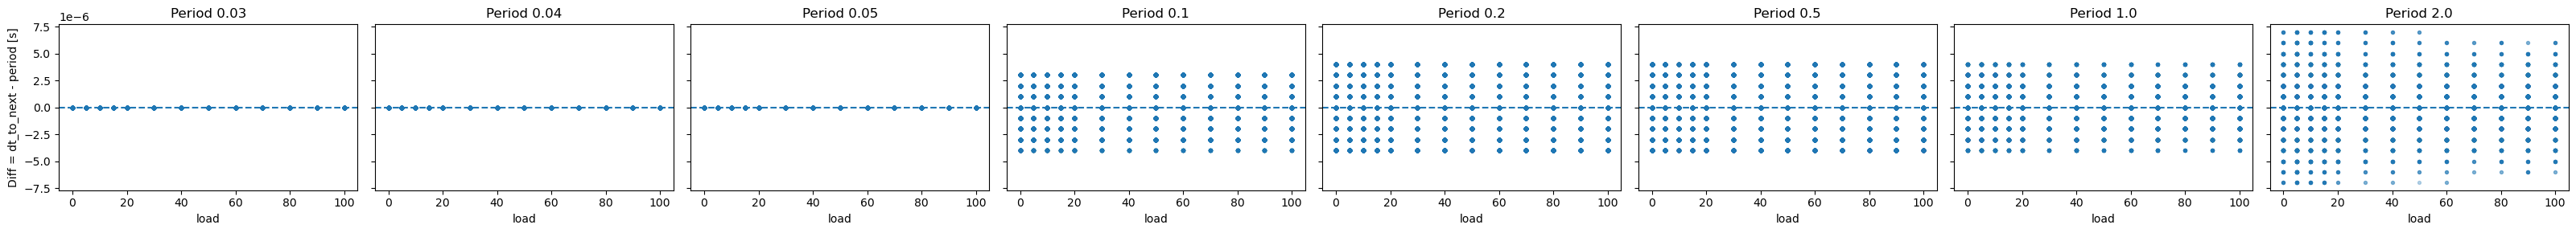

In [159]:
# display the time differences for each period according to the load

data= df_time_updated
periods = sorted(data["period"].unique())
loads = sorted(data["load"].unique())


fig, axes = plt.subplots(
    1, len(periods),
    figsize=(4 * len(periods), 3),
    sharey=True
)

if len(loads) == 1:
    axes = [axes]
    
for ax, period in zip(axes, periods):
    sub = data[data["period"] == period]

    # Optional: sort so periods appear nicely ordered on x
    sub = sub.sort_values("load")
    # Scatter of all points (many per period)
    ax.scatter(sub["load"], sub["diff"], alpha=0.3, s=8)
    ax.axhline(0, linestyle="--")

    ax.set_title(f"Period {period}")
    ax.set_xlabel("load")
    if ax is axes[0]:
        ax.set_ylabel("Diff = dt_to_next - period [s]")
plt.tight_layout()
plt.show()


<Axes: xlabel='period', ylabel='diff'>

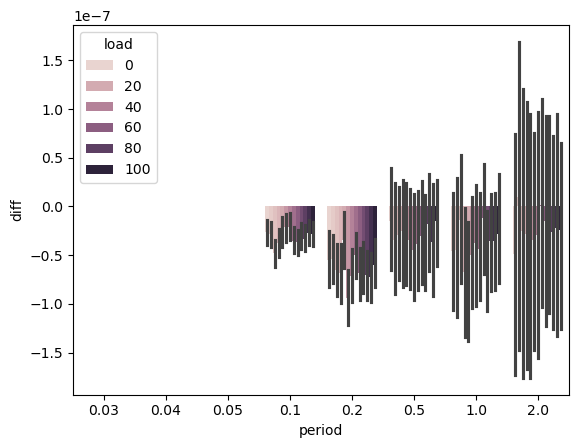

In [162]:
sns.barplot(data= df_time_updated, x='period', y='diff',hue='load')

In [163]:
df_time_updated.to_csv(output_directory+'energylogger_delays.csv')

In [164]:
df_time_updated.head(5)

,duration_s,dt_to_next,period,diff,load,ID
0,0.510056,0.03,0.03,2.775558e-17,40,3
1,0.570055,0.03,0.03,2.775558e-17,40,3
2,0.600055,0.03,0.03,2.775558e-17,40,3
3,0.630055,0.03,0.03,-8.326673e-17,40,3
4,0.660055,0.03,0.03,2.775558e-17,40,3


In [165]:
# Energy influence from period and load

In [172]:
dfs.head(5)

,ID,round,load,period,filename,duration,3V7_WL_SW,3V3_SYS,1V8_SYS,DDR_VDD2,DDR_VDDQ,1V1_SYS,0V8_SW,VDD_CORE,3V3_DAC,3V3_ADC,0V8_AON,HDMI
0,0,11,40,0.05,pmic_log_7_0_0.04s_20251104_184711.csv,79.960475,0.140380,58.878675,22.765752,0.075543,0.002329,16.538686,18.685214,101.346931,0.048742,0.150571,0.221679,6.278027
1,1,30,0,1.00,pmic_log_7_0_0.04s_20251104_184711.csv,79.509937,0.106753,57.845695,21.656643,0.029629,0.000000,16.439292,18.542764,39.774640,0.063474,0.160540,0.219406,6.397245
2,2,28,80,0.10,pmic_log_7_0_0.04s_20251104_184711.csv,79.910289,0.157711,58.228421,22.799463,0.036437,0.000208,16.595216,18.834682,131.361186,0.049042,0.139115,0.223933,6.163154
3,3,10,40,0.03,pmic_log_7_0_0.04s_20251104_184711.csv,79.979996,0.149192,58.907408,22.758280,0.045437,0.000910,16.530613,18.682645,98.525952,0.052043,0.152501,0.220951,6.243559
4,4,6,5,0.10,pmic_log_7_0_0.04s_20251104_184711.csv,79.910750,0.044217,60.461582,22.651469,0.003989,0.000000,16.495240,18.594791,66.962832,0.055561,0.151554,0.219819,6.384793


In [174]:
## Influence by period 

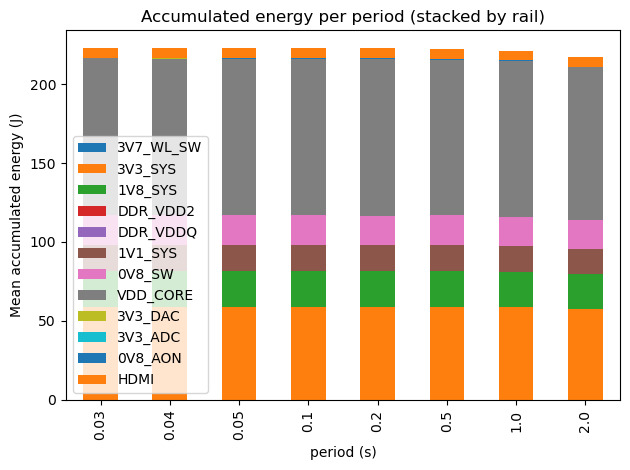

In [176]:
mean_by_period = (
    dfs.groupby("period", as_index=False)[energy_columns]
    .mean()
)

# print(mean_by_load)

import matplotlib.pyplot as plt

plot_df = mean_by_period.set_index("period")[energy_columns]

ax = plot_df.plot(kind="bar", stacked=True)
ax.set_xlabel("period (s)")
ax.set_ylabel("Mean accumulated energy (J)")
ax.set_title("Accumulated energy per period (stacked by rail)")
plt.tight_layout()
plt.show()

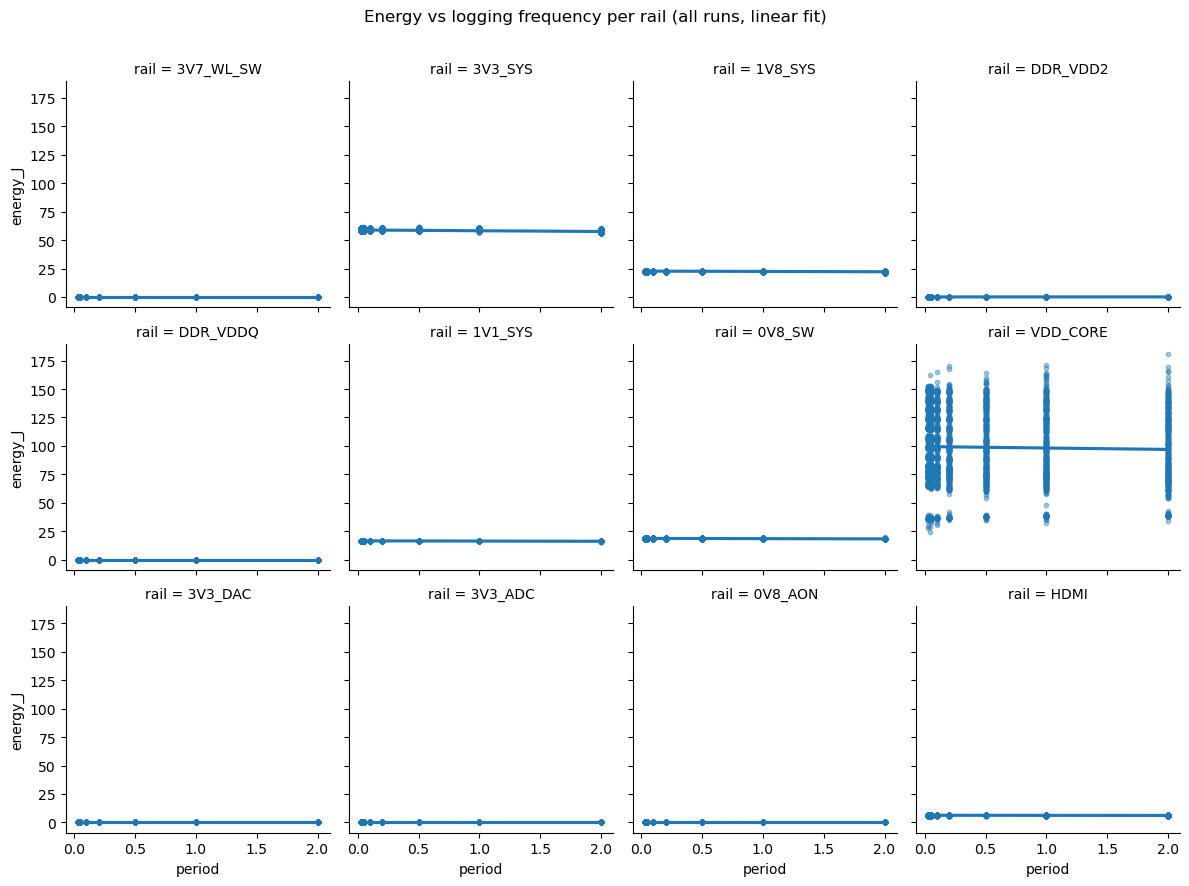

In [178]:

results = []
#dfs["freq_hz"] = 1.0 / dfs["period"]


df_melt = dfs.melt(
    id_vars=["period", "load"],
    value_vars=energy_columns,
    var_name="rail",
    value_name="energy_J")
    
sns.lmplot(
    data=df_melt,
    x="period",
    y="energy_J",
    col="rail",
    col_wrap=4,          # 4 plots per row; adjust as you like
    ci=None,
    height=3,
    scatter_kws={"s": 10, "alpha": 0.4}
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Energy vs logging frequency per rail (all runs, linear fit)")
plt.show()

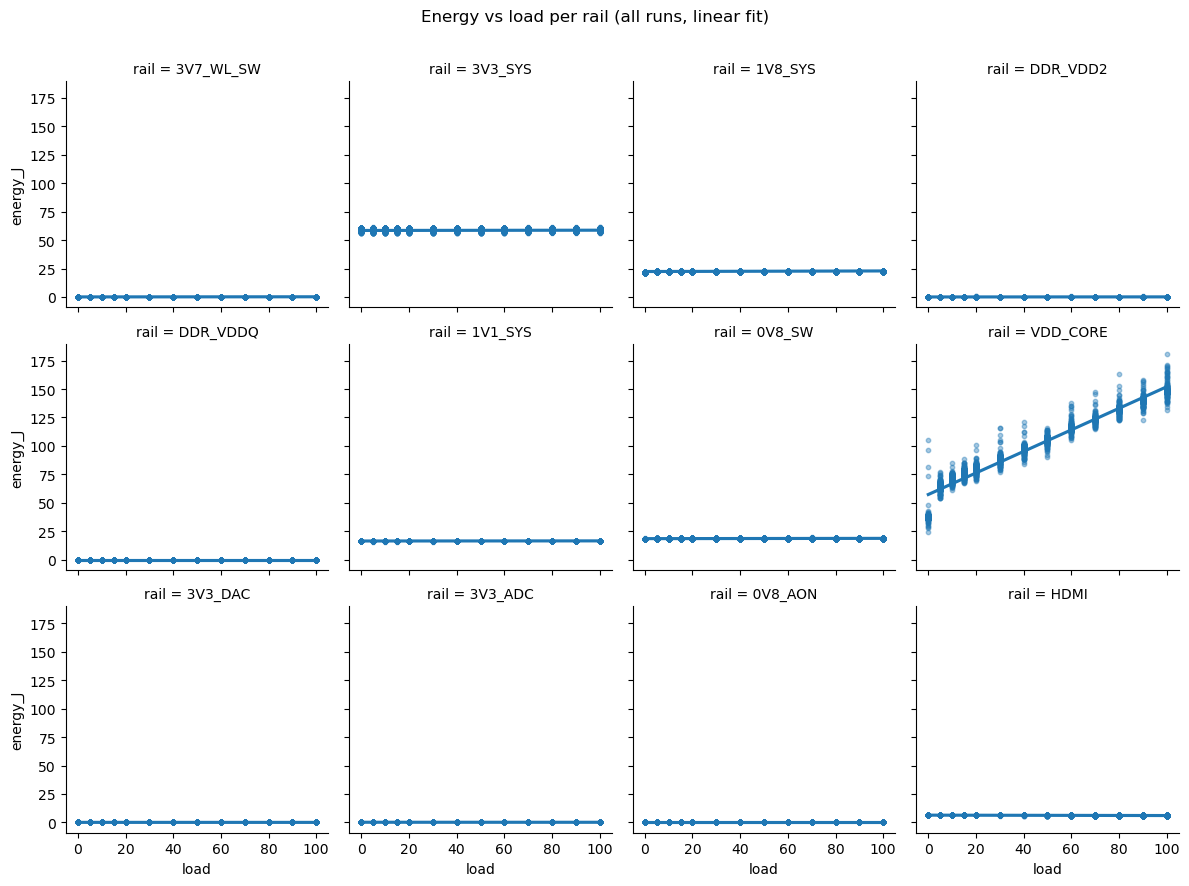

In [181]:
sns.lmplot(
    data=df_melt,
    x="load",
    y="energy_J",
    col="rail",
    col_wrap=4,          # 4 plots per row; adjust as you like
    ci=None,
    height=3,
    scatter_kws={"s": 10, "alpha": 0.4}
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Energy vs load per rail (all runs, linear fit)")
plt.show()

# Overview of the impact of periods 

In the following correlation between energy and load and delay_factor we see that: 

- Real, load-dependent delays only happen at the two shortest periods (0.01 and 0.02 s).

- For ≥ 0.2 s (and practically ≥ 0.05 in your data), delay_factor is ~0 → no kernel / logger pressure.
Across almost all rails:

## There is a clear separation line for the periods:

The overloaded 10–20 ms sampling regime (0.01–0.02 s), where delay grows with load and many rails show high corr with both load and delay,
and the stable ≥30 ms regime, where delay is essentially noise and only load remains a substantive predictor.

### 0.01–0.02 s (overloaded regime)

corr with load: large in magnitude (often > 0.7, up to ~1.0).

corr with delay_factor: also large and very similar to corr(load).

That’s exactly where we know dt_s is far from period and depends on load.

### ≥ 0.03 s (stable timing)

corr with load: many rails stay high (strong or moderate), but not monotone in period.

corr with delay_factor: mostly small, noisy, or sign-flipping. Some values creep up to 0.1–0.3, but that doesn’t mean the effect is big – only that there’s some linear association in very tiny variations.


The rails that matter for CPU work (VDD_CORE, 0V8_SW, 0V8_AON, 1V1_SYS, 1V8_SYS, DDR_VDD2, 3V3_SYS) are:
strongly or moderately load-dependent across all periods, delay-dependent only when you are sampling too aggressively.

Several other rails (3V7_WL_SW, DDR_VDDQ, DAC/ADC, HDMI) behave differently (moderate positive or strong negative load correlations), which is useful evidence when you discuss “which parts of the SoC are actually responding to the CPU workload vs just following along”.

In [185]:
df_time_updated

,duration_s,dt_to_next,period,diff,load,ID
0,0.510056,0.030000,0.03,2.775558e-17,40,3
1,0.570055,0.030000,0.03,2.775558e-17,40,3
2,0.600055,0.030000,0.03,2.775558e-17,40,3
3,0.630055,0.030000,0.03,-8.326673e-17,40,3
4,0.660055,0.030000,0.03,2.775558e-17,40,3
...,...,...,...,...,...,...
2154930,70.000057,2.000000,2.00,0.000000e+00,15,3621
2154931,72.000057,2.000003,2.00,3.000000e-06,15,3621
2154932,74.000060,2.000000,2.00,0.000000e+00,15,3621
2154933,76.000060,1.999999,2.00,-1.000000e-06,15,3621


In [187]:
delay_stats = (
    df_time_updated
    .assign(dt_s=lambda d: d["period"] + d["diff"])  # reconstruct actual dt per sample
    .groupby(["ID", "load", "period"], as_index=False)
    .agg(
        mean_dt   = ("dt_s", "mean"),
        p99_dt    = ("dt_s", lambda x: x.quantile(0.99)),
        max_dt    = ("dt_s", "max"),
        duration_s=("duration_s", "max"),   # total elapsed time for that log
        n_samples = ("dt_s", "size")
    )
)

delay_stats["delay_factor"] = delay_stats["mean_dt"] - delay_stats["period"]
# which is also just mean(diff), since mean_dt = period + mean(diff)


In [188]:
merged = dfs.merge(
    delay_stats,
    on=["ID", "period", "load"],
    how="inner",
)

merged.head(5)

,ID,round,load,period,filename,duration,3V7_WL_SW,3V3_SYS,1V8_SYS,DDR_VDD2,...,3V3_DAC,3V3_ADC,0V8_AON,HDMI,mean_dt,p99_dt,max_dt,duration_s,n_samples,delay_factor
0,0,11,40,0.05,pmic_log_7_0_0.04s_20251104_184711.csv,79.960475,0.140380,58.878675,22.765752,0.075543,...,0.048742,0.150571,0.221679,6.278027,0.05,0.050000,0.050000,80.450054,935,2.081668e-17
1,1,30,0,1.00,pmic_log_7_0_0.04s_20251104_184711.csv,79.509937,0.106753,57.845695,21.656643,0.029629,...,0.063474,0.160540,0.219406,6.397245,1.00,1.000004,1.000004,77.000059,61,-9.836066e-08
2,2,28,80,0.10,pmic_log_7_0_0.04s_20251104_184711.csv,79.910289,0.157711,58.228421,22.799463,0.036437,...,0.049042,0.139115,0.223933,6.163154,0.10,0.100003,0.100003,80.400056,760,-5.131579e-08
3,3,10,40,0.03,pmic_log_7_0_0.04s_20251104_184711.csv,79.979996,0.149192,58.907408,22.758280,0.045437,...,0.052043,0.152501,0.220951,6.243559,0.03,0.030000,0.030000,80.460054,1444,5.898060e-17
4,4,6,5,0.10,pmic_log_7_0_0.04s_20251104_184711.csv,79.910750,0.044217,60.461582,22.651469,0.003989,...,0.055561,0.151554,0.219819,6.384793,0.10,0.100003,0.100003,80.400054,772,-2.720207e-08


In [191]:

periods = sorted(list(merged['period'].unique()))
for rail in energy_columns:
    print(f'rail: {rail}')
    for period in periods:
        sub = merged[np.isclose(merged["period"], period)]
        corr_load = sub[rail].corr(sub["load"])
        corr_delay = sub[rail].corr(sub["delay_factor"])
        print(f'\tperiod: {period}, correlation load: {corr_load}, correlation delay: {corr_delay}')

rail: 3V7_WL_SW
	period: 0.03, correlation load: 0.7375616091043801, correlation delay: 0.012784729025294515
	period: 0.04, correlation load: 0.7584192513944554, correlation delay: -0.025088252333583215
	period: 0.05, correlation load: 0.7503209358275869, correlation delay: 0.02210104590703158
	period: 0.1, correlation load: 0.7778288295402614, correlation delay: 0.05540615890280542
	period: 0.2, correlation load: 0.7620357058449004, correlation delay: -0.030177288508675397
	period: 0.5, correlation load: 0.7595862821310734, correlation delay: -0.03886964441485214
	period: 1.0, correlation load: 0.7179542569920901, correlation delay: 0.0496256284612516
	period: 2.0, correlation load: 0.5865843933536855, correlation delay: 0.04498007839201398
rail: 3V3_SYS
	period: 0.03, correlation load: 0.08638565982697555, correlation delay: 0.011952411422409576
	period: 0.04, correlation load: 0.09191108751691004, correlation delay: -0.01746525236753569
	period: 0.05, correlation load: 0.09011607188

In [200]:
df_period = mean_by_period.copy()
df_period["freq_hz"] = 1.0 / df_period["period"]

# all rails = all columns except 'period' and 'freq_hz'
rail_cols = [c for c in df_period.columns if c not in ("period", "freq_hz")]
rail_cols

['3V7_WL_SW',
 '3V3_SYS',
 '1V8_SYS',
 'DDR_VDD2',
 'DDR_VDDQ',
 '1V1_SYS',
 '0V8_SW',
 'VDD_CORE',
 '3V3_DAC',
 '3V3_ADC',
 '0V8_AON',
 'HDMI']

In [202]:
dfs.to_csv(output_directory+"EnergyLogger_summarized.csv")

<Axes: >

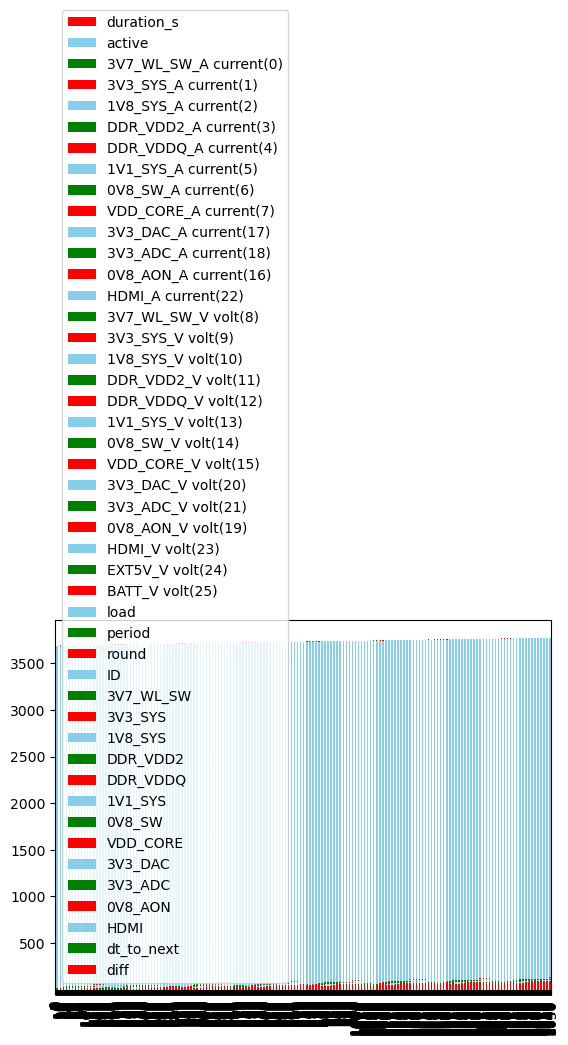

In [206]:
df.plot(kind='bar', stacked=True, color=['red', 'skyblue', 'green'])